# Clase 4 · Regresión lineal simple y múltiple

**INF-396 Introducción a la Ciencia de Datos** · Universidad Técnica Federico Santa María

Objetivos de la sesión: ajustar la primera regresión y leer sus residuos, medir el impacto de sacar filas y atípicos, ponderar una regresión con los factores de expansión, y dar el paso a la **regresión múltiple**: modelos con más de una variable explicativa, con variables categóricas como dummies.

## La pregunta de partida

¿Las comunas de menor ingreso viajan más tiempo? Esa es la relación que queremos
modelar: la **duración media del viaje** es lo que queremos predecir (la
variable y); el **ingreso medio del hogar** es la variable independiente (la
variable x). Comuna por comuna.

El plan: construir la tabla que junta ambas variables (una fila por comuna, con
medias ponderadas), mirar la relación, y ajustarle la primera recta.

## 1. Preparación

Reconstruimos en pocas celdas la tabla ponderada por comuna y su recta: son los merges y las medias ponderadas de la clase 02, aplicadas por comuna.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
# Seaborn: gráficos estadísticos de alto nivel, sobre Matplotlib
import seaborn as sns
# statsmodels: la librería estadística de esta clase
import statsmodels.api as sm

# Gráficos más nítidos en pantallas de alta resolución
%config InlineBackend.figure_format = "retina"


In [2]:
BASE = "datos/eod_stgo/"  # los datos vienen incluidos al clonar el repositorio
# Para correrlo sin clonar (por ejemplo en Colab):
# BASE = ("https://raw.githubusercontent.com/daniopitz/cienciadatos/"
#         "main/datos/eod_stgo/")

In [3]:
viajes = pd.read_csv(BASE + "viajes.csv", sep=";", decimal=",", low_memory=False)
hogares = pd.read_csv(BASE + "Hogares.csv", sep=";", decimal=",", low_memory=False)
viajes.shape, hogares.shape

((113591, 35), (18264, 21))

In [4]:
# La tabla por comuna: medias ponderadas por el factor (clase 02)
viajes_final = viajes.merge(
    hogares[["Hogar", "Comuna", "IngresoHogar", "NumVeh", "NumPer"]], on="Hogar")
viajes_final = viajes_final.dropna(
    subset=["FactorLaboralNormal", "TiempoViaje", "IngresoHogar"]).copy()
viajes_final.head()

,Hogar,Persona,Viaje,Etapas,ComunaOrigen,ComunaDestino,SectorOrigen,SectorDestino,ZonaOrigen,ZonaDestino,...,FactorLaboralNormal,FactorSabadoNormal,FactorDomingoNormal,FactorLaboralEstival,FactorFindesemanaEstival,CodigoTiempo,Comuna,IngresoHogar,NumVeh,NumPer
0,173431,17343102,1734310202,1,94.0,94.0,2.0,2.0,400,407,...,1.000000,NaN,NaN,NaN,NaN,0.0,MAIPU,789356,0,4
1,173441,17344101,1734410101,2,94.0,71.0,2.0,3.0,407,307,...,1.127220,NaN,NaN,NaN,NaN,0.0,MAIPU,633883,0,4
2,173441,17344101,1734410102,2,71.0,94.0,3.0,2.0,307,407,...,1.127220,NaN,NaN,NaN,NaN,0.0,MAIPU,633883,0,4
3,173441,17344103,1734410301,2,94.0,91.0,2.0,3.0,407,437,...,1.127220,NaN,NaN,NaN,NaN,0.0,MAIPU,633883,0,4
4,173441,17344103,1734410302,2,91.0,94.0,3.0,2.0,437,407,...,1.052764,NaN,NaN,NaN,NaN,0.0,MAIPU,633883,0,4


In [5]:
w = viajes_final["FactorLaboralNormal"]
w.head()

0    1.000000
1    1.127220
2    1.127220
3    1.127220
4    1.052764
Name: FactorLaboralNormal, dtype: float64

In [6]:
for col in ["IngresoHogar", "TiempoViaje"]:
    viajes_final["w_" + col] = w * viajes_final[col]

viajes_final.head()

,Hogar,Persona,Viaje,Etapas,ComunaOrigen,ComunaDestino,SectorOrigen,SectorDestino,ZonaOrigen,ZonaDestino,...,FactorDomingoNormal,FactorLaboralEstival,FactorFindesemanaEstival,CodigoTiempo,Comuna,IngresoHogar,NumVeh,NumPer,w_IngresoHogar,w_TiempoViaje
0,173431,17343102,1734310202,1,94.0,94.0,2.0,2.0,400,407,...,NaN,NaN,NaN,0.0,MAIPU,789356,0,4,789356.000000,70.000000
1,173441,17344101,1734410101,2,94.0,71.0,2.0,3.0,407,307,...,NaN,NaN,NaN,0.0,MAIPU,633883,0,4,714525.500178,118.358084
2,173441,17344101,1734410102,2,71.0,94.0,3.0,2.0,307,407,...,NaN,NaN,NaN,0.0,MAIPU,633883,0,4,714525.500178,101.449786
3,173441,17344103,1734410301,2,94.0,91.0,2.0,3.0,407,437,...,NaN,NaN,NaN,0.0,MAIPU,633883,0,4,714525.500178,61.997092
4,173441,17344103,1734410302,2,91.0,94.0,3.0,2.0,437,407,...,NaN,NaN,NaN,0.0,MAIPU,633883,0,4,667328.923703,157.914534


In [7]:
suma = viajes_final.groupby("Comuna").sum(numeric_only=True)
suma.head()

,Hogar,Persona,Viaje,Etapas,ComunaOrigen,ComunaDestino,SectorOrigen,SectorDestino,ZonaOrigen,ZonaDestino,...,FactorSabadoNormal,FactorDomingoNormal,FactorLaboralEstival,FactorFindesemanaEstival,CodigoTiempo,IngresoHogar,NumVeh,NumPer,w_IngresoHogar,w_TiempoViaje
Comuna,,,,,,,,,,,,,,,,,,,,,
BUIN,89661110,8966113146,896611316493,961,108285.0,111949.0,5979.0,5979.0,658345,658446,...,0.0,0.0,0.0,0.0,134.0,546475044,316,3501,7.052428e+08,32020.235435
CALERA DE TANGO,64482902,6448291776,644829178694,701,65894.0,64974.0,2978.0,2960.0,444799,440821,...,0.0,0.0,0.0,0.0,123.0,382028274,452,2686,4.668899e+08,30455.905792
CERRILLOS,80456874,8045689141,804568915428,903,203648.0,201903.0,1740.0,1746.0,101566,102724,...,0.0,0.0,0.0,0.0,46.0,444460094,341,2857,5.365975e+08,32291.613596
CERRO NAVIA,119238371,11923839885,1192383990677,1432,289261.0,285565.0,2455.0,2459.0,176182,181066,...,0.0,0.0,0.0,0.0,123.0,514473060,371,4536,6.180795e+08,48622.725252
COLINA,156220937,15622096652,1562209667243,1263,102390.0,103870.0,1415.0,1434.0,800165,799662,...,0.0,0.0,0.0,0.0,67.0,759559305,307,4900,9.198311e+08,47121.276054


In [8]:
por_comuna = pd.DataFrame({
    "ingreso": suma["w_IngresoHogar"] / suma["FactorLaboralNormal"],
    "duracion": suma["w_TiempoViaje"] / suma["FactorLaboralNormal"],
    "n": viajes_final.groupby("Comuna").size()}).reset_index()
por_comuna = por_comuna[por_comuna["n"] >= 200]
len(por_comuna)

45

In [9]:
por_comuna.head()

,Comuna,ingreso,duracion,n
0,BUIN,611584.779504,27.767868,889
1,CALERA DE TANGO,609311.812531,39.746297,629
2,CERRILLOS,578682.733281,34.824237,760
3,CERRO NAVIA,457758.557018,36.010691,1113
4,COLINA,636524.561820,32.607995,1177


In [10]:
# La primera recta y sus residuos (la única vez con polyfit; luego, statsmodels)
pendiente, intercepto = np.polyfit(por_comuna["ingreso"] / 1e6,
                                   por_comuna["duracion"], 1)
print(f"pendiente: {pendiente:.2f}, intercepto: {intercepto:.2f}")

pendiente: -4.81, intercepto: 38.34


In [11]:
por_comuna["prediccion"] = intercepto + pendiente * por_comuna["ingreso"] / 1e6
por_comuna["residuo"] = por_comuna["duracion"] - por_comuna["prediccion"]
por_comuna.head()

,Comuna,ingreso,duracion,n,prediccion,residuo
0,BUIN,611584.779504,27.767868,889,35.390729,-7.622861
1,CALERA DE TANGO,609311.812531,39.746297,629,35.401672,4.344625
2,CERRILLOS,578682.733281,34.824237,760,35.549138,-0.724901
3,CERRO NAVIA,457758.557018,36.010691,1113,36.131335,-0.120645
4,COLINA,636524.561820,32.607995,1177,35.270655,-2.662659


### La misma regresión, ahora en statsmodels

`polyfit` entrega la recta y nada más. `statsmodels` ajusta el mismo modelo por
mínimos cuadrados (OLS) y entrega además todo lo que la recta no dice: errores
estándar, valores p y R². La única diferencia de uso: el intercepto se pide
explícitamente con `add_constant`.

In [12]:
X = sm.add_constant(por_comuna["ingreso"] / 1e6)
modelo_simple = sm.OLS(por_comuna["duracion"], X).fit()

# Los mismos numeros que polyfit
modelo_simple.params

const      38.335244
ingreso    -4.814566
dtype: float64

In [13]:
modelo_simple.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               duracion   R-squared:                       0.117
Model:                            OLS   Adj. R-squared:                  0.097
Method:                 Least Squares   F-statistic:                     5.707
Date:                Fri, 04 Sep 2026   Prob (F-statistic):             0.0214
Time:                        11:57:41   Log-Likelihood:                -139.50
No. Observations:                  45   AIC:                             283.0
Df Residuals:                      43   BIC:                             286.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         38.3352      1.773     21.622      0.000      34.760      41.911
ingreso       -4.8146      2.015     -2.389      0.021      -8.879      -0.750
==============================================================================
Omnibus:                        2.948   Durbin-Watson:                   1.936
Prob(Omnibus):                  0.229   Jarque-Bera (JB):                2.776
Skew:                           0.556   Prob(JB):                        0.250
Kurtosis:                       2.504   Cond. No.                         4.12
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

### Dos columnas nuevas: el intervalo de confianza y el valor p

La pendiente estimada es −4,8, pero viene de una muestra de 45 comunas: otra
muestra habría dado otro número. El summary trae dos herramientas para
cuantificar esa incertidumbre, y ambas son nuevas para nosotros.

**El intervalo de confianza** (columnas `[0.025, 0.975]`) responde la pregunta:
¿cuánto habría variado esta recta si la muestra hubiera sido otra? Es el rango de
valores del coeficiente compatibles con los datos: el procedimiento que lo construye
captura el valor verdadero el 95% de las veces. No es "el coeficiente está aquí
con probabilidad 95%", sino "así de precisa es nuestra estimación".

In [14]:
modelo_simple.conf_int()

,0,1
const,34.759648,41.910841
ingreso,-8.878964,-0.750168


La lectura: la pendiente está entre **−8,9 y −0,8** minutos por millón. Es un
rango ancho (la estimación es imprecisa, con solo 45 comunas), pero **no toca el
cero**: todos los valores compatibles con los datos son negativos.

**El valor p** (columna `P>|t|`) responde otra pregunta: si el ingreso no tuviera
relación con la duración (pendiente verdadera igual a cero), ¿qué tan raro sería
obtener por puro azar de la muestra una pendiente tan grande como esta? Aquí
p = 0,021: pasaría en 2 de cada 100 muestras. Es chico, así que el resultado es
**incompatible con el azar** bajo el umbral usual de 0,05.

Las dos herramientas cuentan la misma historia (un intervalo que excluye el cero
equivale a p < 0,05), y por ahora basta esta lectura: la definición formal, con
hipótesis y umbrales, se ve en detalle la próxima clase.

### De dónde sale el error: el cálculo a mano

El error estándar de la pendiente se calcula con dos ingredientes del único
ajuste que hicimos: el **ruido** (la desviación típica de los residuos,
s = raíz de Σe²/(n−2); el n−2 descuenta los dos parámetros ya estimados) y la
**palanca** (la dispersión de los x, Σ(x−x̄)²). La fórmula:

$$SE(b) = \frac{s}{\sqrt{\sum_i (x_i - \bar{x})^2}}$$

En nuestra recta, **x es el ingreso** (en millones), **y es la duración**, y los
**e** son los residuos: lo mismo que el código llama `ingreso`, `duracion` y
`modelo_simple.resid`.

Más ruido alrededor de la recta agranda el error; ingresos más repartidos y más
puntos lo achican (la recta queda anclada en los extremos y no puede girar).
Comprobemos que reproduce el `std err` del summary:

In [15]:
n = len(por_comuna)
s_resid = np.sqrt((modelo_simple.resid**2).sum() / (n - 2))
x = por_comuna["ingreso"] / 1e6   # la x de la formula: el ingreso
sxx = ((x - x.mean())**2).sum()

se_a_mano = s_resid / np.sqrt(sxx)
print(f"s (residuos): {s_resid:.2f} min | Sxx: {sxx:.2f}")
print(f"SE a mano:        {se_a_mano:.3f}")
print(f"SE de statsmodels: {modelo_simple.bse['ingreso']:.3f}")

s (residuos): 5.50 min | Sxx: 7.43
SE a mano:        2.015
SE de statsmodels: 2.015


Idénticos. Y el intervalo es la estimación más y menos t veces ese error:
−4,81 ± 2,017 · 2,0 = [−8,9, −0,8], donde 2,017 es el cuantil t con n − 2 = 43
grados de libertad (el "± 2 desviaciones" del 95%). Nada de ajustar varios
modelos: la fórmula predice cuánto variaría la pendiente entre muestras usando
solo los residuos y los x de este ajuste. El bootstrap de la próxima clase llega
al mismo número por el camino empírico: remuestrear y reajustar muchas veces.

Y el gráfico del modelo: la nube de comunas con la recta ajustada encima. La
predicción del modelo para cualquier ingreso es un punto de esa recta.

In [16]:
x_linea = np.linspace(0.3, 2.5, 50)
x_linea

array([0.3       , 0.34489796, 0.38979592, 0.43469388, 0.47959184,
       0.5244898 , 0.56938776, 0.61428571, 0.65918367, 0.70408163,
       0.74897959, 0.79387755, 0.83877551, 0.88367347, 0.92857143,
       0.97346939, 1.01836735, 1.06326531, 1.10816327, 1.15306122,
       1.19795918, 1.24285714, 1.2877551 , 1.33265306, 1.37755102,
       1.42244898, 1.46734694, 1.5122449 , 1.55714286, 1.60204082,
       1.64693878, 1.69183673, 1.73673469, 1.78163265, 1.82653061,
       1.87142857, 1.91632653, 1.96122449, 2.00612245, 2.05102041,
       2.09591837, 2.14081633, 2.18571429, 2.23061224, 2.2755102 ,
       2.32040816, 2.36530612, 2.41020408, 2.45510204, 2.5       ])

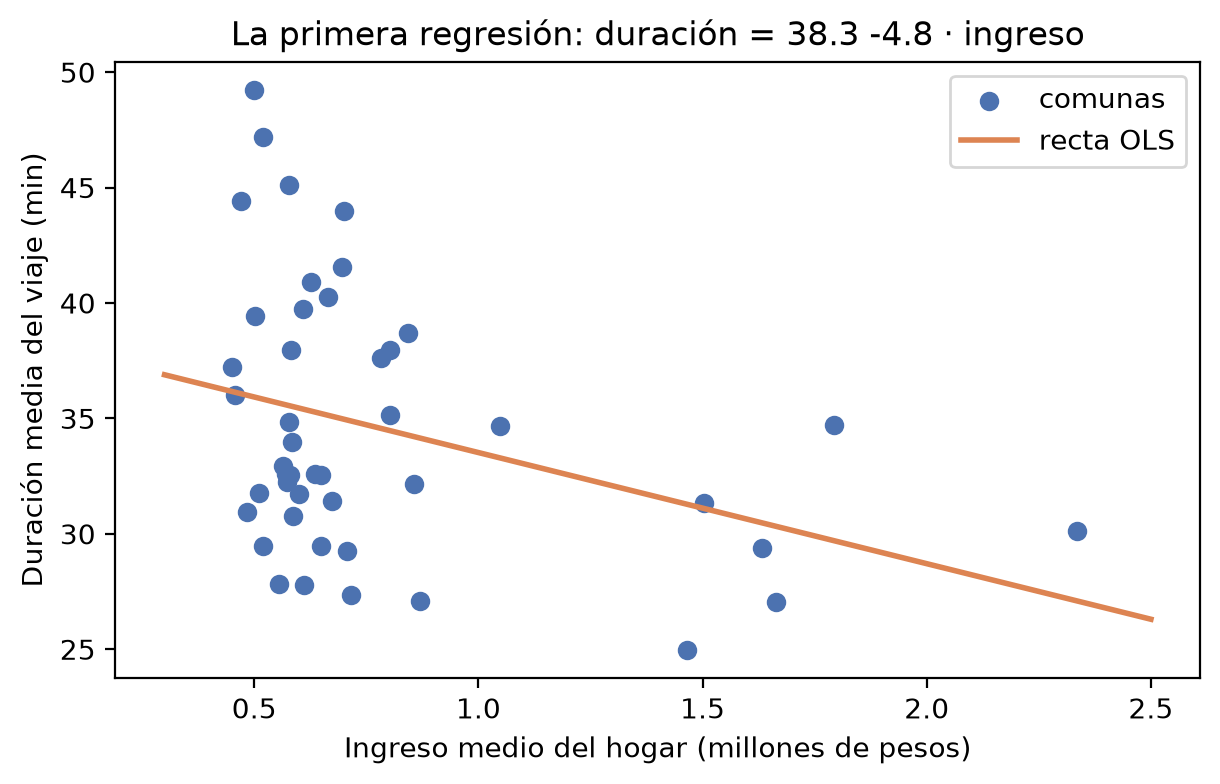

In [17]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(por_comuna["ingreso"] / 1e6, por_comuna["duracion"],
           color="#4C72B0", label="comunas")

x_linea = np.linspace(0.3, 2.5, 50)
y_linea = modelo_simple.params["const"] + modelo_simple.params["ingreso"] * x_linea
ax.plot(x_linea, y_linea, color="#DD8452", linewidth=2, label="recta OLS")

ax.set_xlabel("Ingreso medio del hogar (millones de pesos)")
ax.set_ylabel("Duración media del viaje (min)")
ax.set_title("La primera regresión: duración = "
             f"{modelo_simple.params['const']:.1f} "
             f"{modelo_simple.params['ingreso']:+.1f} · ingreso")
ax.legend()
plt.show()

## 2. Filas, atípicos y ponderación

La primera pregunta sobre el modelo: ¿cuánto cambia al sacar una sola fila?

### El impacto de sacar una fila

**Objetivo:** medir cuánto cambian la correlación y la recta al sacar una sola fila, comparando con y sin.

En la clase 2 medimos el impacto de sacar filas comparando un resumen con y sin (la desviación se movía; el IQR no). Con dos variables el mismo experimento se amplifica: una fila mueve varios resúmenes a la vez, y no a todos por igual. La comuna de ingreso más extremo es Lo Barnechea; la sacamos y comparamos todo:

In [18]:
sin_lb = por_comuna[por_comuna["Comuna"] != "LO BARNECHEA"]

print("Con Lo Barnechea: r =", round(por_comuna["ingreso"].corr(por_comuna["duracion"]), 2))
print("Sin Lo Barnechea: r =", round(sin_lb["ingreso"].corr(sin_lb["duracion"]), 2))

Con Lo Barnechea: r = -0.34
Sin Lo Barnechea: r = -0.34


In [19]:
pend2, inter2 = np.polyfit(sin_lb["ingreso"] / 1e6, sin_lb["duracion"], 1)

print("Pendiente  con:", round(pendiente, 1), "| sin:", round(pend2, 1))
print("Intercepto con:", round(intercepto, 1), "| sin:", round(inter2, 1))

Pendiente  con: -4.8 | sin: -5.8
Intercepto con: 38.3 | sin: 39.0


In [20]:
# El mismo experimento sobre R cuadrado: la fraccion de varianza explicada
r_con = por_comuna["ingreso"].corr(por_comuna["duracion"])
r_sin = sin_lb["ingreso"].corr(sin_lb["duracion"])

print("R2 con Lo Barnechea:", round(r_con**2, 3))
print("R2 sin Lo Barnechea:", round(r_sin**2, 3))

R2 con Lo Barnechea: 0.117
R2 sin Lo Barnechea: 0.115


No confundir los dos números: **r** mide la fuerza de la asociación lineal
(va de −1 a 1, con signo), y **R²** es la fracción de la varianza de y que el
modelo explica (va de 0 a 1). En la regresión simple, R² es exactamente r al
cuadrado, así que aquí se mueven juntos: casi nada.

El contraste es el punto del experimento: al sacar Lo Barnechea, r y R² casi no
cambian, pero la **pendiente** cambia en un quinto. Cada resumen del modelo
tiene su propia sensibilidad a una fila, y por eso el impacto se mide sobre
todos los que se van a reportar, no sobre uno.

Una sola comuna de 45 no mueve la correlación (−0,34 en ambos casos), pero cambia la pendiente en un quinto (−4,8 a −5,8): cada resumen tiene su propia sensibilidad. Por eso el impacto de sacar una fila se mide siempre con y sin, y sobre **todos** los resúmenes que el análisis usa. Los puntos extremos en x, como Lo Barnechea, tienen nombre propio en regresión (puntos de apalancamiento) y los verán formalmente en la clase 6.

Una advertencia de escala: en esta tabla agregada, sacar una "fila" es sacar una comuna completa, miles de viajes. Repitamos el experimento donde corresponde: en un modelo desagregado, hogar por hogar.

### Otro modelo: la motorización

**Objetivo:** modelar cuántos vehículos tiene un hogar según su ingreso, ahora con datos desagregados (un hogar por fila).

Los modelos de propiedad de vehículos son estándar en ingeniería de transporte: ¿cuántos autos tendrá un hogar según su ingreso? Aquí cada fila es un hogar de verdad, 18.264, no un agregado. Como la conclusión es sobre la ciudad, usamos las fórmulas ponderadas; las medias son las de la clase 2,

$$\bar{x}_w = \frac{\sum_i w_i\,x_i}{\sum_i w_i} \qquad \bar{y}_w = \frac{\sum_i w_i\,y_i}{\sum_i w_i}$$

y la pendiente y el intercepto, los de mínimos cuadrados con cada término pesado por su factor $w_i$:

$$b_w = \frac{\sum_i w_i\,(x_i - \bar{x}_w)(y_i - \bar{y}_w)}{\sum_i w_i\,(x_i - \bar{x}_w)^2} \qquad a_w = \bar{y}_w - b_w\,\bar{x}_w$$

donde $w_i$ es el factor de expansión del hogar $i$, y $\bar{x}_w$, $\bar{y}_w$ las medias ponderadas.

El código que sigue es esta fórmula, línea por línea:

In [21]:
h = hogares.dropna(subset=["IngresoHogar", "NumVeh", "Factor"]).copy()

x = h["IngresoHogar"] / 1e6
y = h["NumVeh"]
w = h["Factor"]

# Las medias ponderadas, como en la clase 2
xw = (w * x).sum() / w.sum()
yw = (w * y).sum() / w.sum()
print(round(xw, 2), round(yw, 2))

0.73 0.57


In [22]:
# La fórmula de la pendiente ponderada, tal cual
pend_h = (w * (x - xw) * (y - yw)).sum() / (w * (x - xw)**2).sum()
inter_h = yw - pend_h * xw

print("Pendiente: ", round(pend_h, 2), "vehículos por millón")
print("Intercepto:", round(inter_h, 2), "vehículos")

Pendiente:  0.5 vehículos por millón
Intercepto: 0.2 vehículos


La misma regresión ponderada existe en statsmodels con nombre propio: **WLS** (weighted least squares, mínimos cuadrados ponderados), que recibe los pesos en `weights`:

In [23]:
# WLS: la versión ponderada de OLS
modelo_w = sm.WLS(y, sm.add_constant(x), weights=w).fit()

# Lado a lado y con más decimales: ¿dan lo mismo?
print("Fórmula a mano : pendiente", round(pend_h, 4),
      "| intercepto", round(inter_h, 4))
print("statsmodels WLS: pendiente", round(modelo_w.params["IngresoHogar"], 4),
      "| intercepto", round(modelo_w.params["const"], 4))

Fórmula a mano : pendiente 0.5014 | intercepto 0.1999
statsmodels WLS: pendiente 0.5014 | intercepto 0.1999


In [24]:
print("R²:", round(modelo_w.rsquared, 3))

R²: 0.261


Iguales hasta el último decimal: la fórmula a mano y la librería son el mismo método.

**Medio vehículo más por cada millón** de ingreso. A nivel de hogar la correlación es 0,47.

Ahora la pregunta del inicio: ¿qué pasa si saco los atípicos de la **variable que quiero predecir**? Según Tukey, en vehículos la cerca queda en 2,5: los hogares con 3 autos o más son atípicos. Primero el boxplot, para verlos:

/var/folders/px/_z85y2bj7j382hbqgh2yzfd00000gn/T/ipykernel_11567/3254019949.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(h["NumVeh"], vert=False)


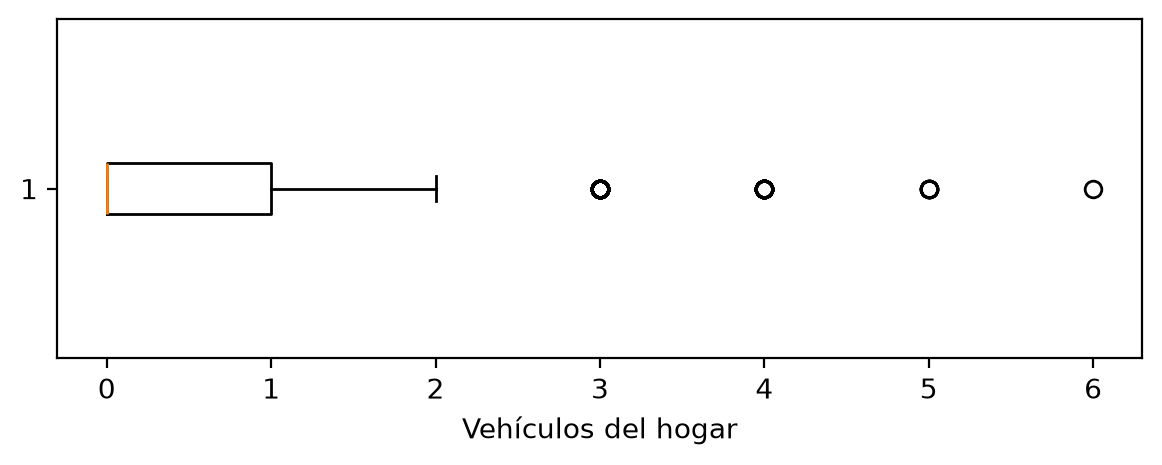

In [25]:
# El boxplot de la variable a predecir
fig, ax = plt.subplots(figsize=(7, 2.2))
ax.boxplot(h["NumVeh"], vert=False)
ax.set_xlabel("Vehículos del hogar")
plt.show()

In [26]:
q1, q3 = h["NumVeh"].quantile([0.25, 0.75])
corte = q3 + 1.5 * (q3 - q1)
print("Corte para outliers:", corte)
sa = h[h["NumVeh"] <= corte]
sa

Corte para outliers: 2.5


,Hogar,Sector,Zona,Comuna,DirCoordX,DirCoordY,Fecha,DiaAsig,TipoDia,Temporada,...,NumVeh,NumBicAdulto,NumBicNino,Propiedad,MontoDiv,ImputadoDiv,MontoArr,ImputadoArr,IngresoHogar,Factor
0,100010,7,786,BUIN,335180.8019,6266420.975,14-04-2013,domingo,2,1,...,1,1,0,2,53000.0,0,100000,0,450845,136.393738
1,100020,7,785,BUIN,338410.2114,6265607.141,10-04-2013,miércoles,1,1,...,1,3,0,1,NaN,0,120000,0,1019369,73.843597
2,100030,7,791,BUIN,327863.8248,6257800.086,23-08-2013,viernes,1,1,...,0,0,0,3,NaN,0,70000,0,80000,180.722809
3,100041,7,791,BUIN,327864.0000,6257800.000,23-08-2013,viernes,1,1,...,0,1,0,1,NaN,0,80000,0,559259,150.379059
4,100052,7,783,BUIN,338480.8152,6267296.941,08-08-2013,jueves,1,1,...,0,0,0,1,NaN,0,117771,1,710309,122.001518
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18259,700990,7,785,BUIN,339104.1011,6263063.925,24-11-2013,domingo,2,1,...,0,1,1,1,NaN,0,100000,0,300000,75.526031
18260,706781,2,69,CERRO NAVIA,338539.1741,6299539.203,24-11-2013,domingo,2,1,...,0,2,2,1,NaN,0,140000,0,695186,174.348663
18261,706791,2,69,CERRO NAVIA,338563.2201,6299580.118,24-11-2013,domingo,2,1,...,0,0,0,1,NaN,0,200000,0,396715,71.358963
18262,743813,5,244,LA GRANJA,349410.2812,6289668.962,24-11-2013,domingo,2,1,...,0,0,0,1,NaN,0,80000,0,318005,68.410446


**Por qué el bigote del boxplot no coincide con la cerca.** La cerca es un
umbral teórico (aquí 2,5) y puede caer en un valor que ningún dato tiene. El
bigote, en cambio, se dibuja en un dato real: el mayor valor observado que no
supera la cerca (aquí 2, porque los vehículos son enteros). Todo lo que queda
sobre la cerca se dibuja como punto atípico. Los dos números son correctos y
dicen cosas distintas: 2,5 es el criterio de corte; 2 es hasta donde llegan los
datos no atípicos.

In [27]:
# La misma fórmula ponderada, sobre los datos recortados
x2= sa["IngresoHogar"] / 1e6
y2=sa["NumVeh"]
w2=sa["Factor"]

In [28]:
xw2 = (w2 * x2).sum() / w2.sum()
yw2 = (w2 * y2).sum() / w2.sum()
pend_s = (w2 * (x2 - xw2) * (y2 - yw2)).sum() / (w2 * (x2 - xw2)**2).sum()
inter_s = yw2 - pend_s * xw2

print("Hogares eliminados:", len(h) - len(sa))
print("Pendiente con:", round(pend_h, 2), "| sin:", round(pend_s, 2))

Hogares eliminados: 236
Pendiente con: 0.5 | sin: 0.44


In [29]:
#ingreso
x.head()

0    0.450845
1    1.019369
2    0.080000
3    0.559259
4    0.710309
Name: IngresoHogar, dtype: float64

In [30]:
#numveh
y.head()

0    1
1    1
2    0
3    0
4    0
Name: NumVeh, dtype: int64

In [31]:
#ingreso min y max
xr = np.array([x.min(), x.max()])
xr

array([ 0. , 14.8])

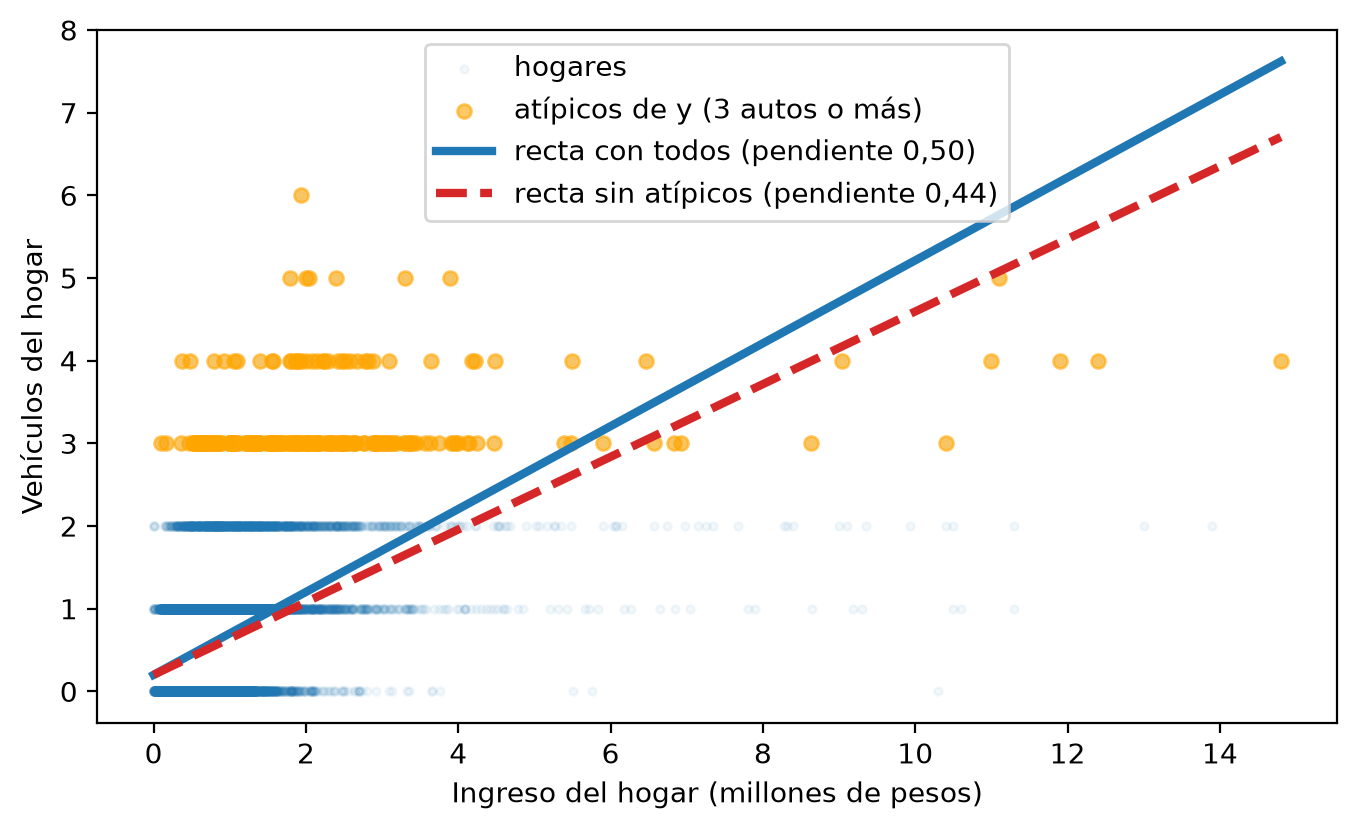

In [32]:
# El impacto, dibujado: las dos rectas sobre los hogares.
# s es el tamaño de cada punto; alpha, su transparencia: con
# 18 mil hogares, alpha=0.05 deja ver dónde se acumulan
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(x, y, alpha=0.05, s=8, label="hogares") #datos completos
ax.scatter(x[y > corte], y[y > corte], s=25, color="orange",alpha=0.6, label="atípicos de y (3 autos o más)") #datos filtrados
ax.plot(xr, inter_h + pend_h * xr, lw=3, color="C0",
        label="recta con todos (pendiente 0,50)") # recta considerando todos los hogares
ax.plot(xr, inter_s + pend_s * xr, lw=3, ls="--", color="C3",
        label="recta sin atípicos (pendiente 0,44)") # recta filtrando hogares

ax.set_xlabel("Ingreso del hogar (millones de pesos)")
ax.set_ylabel("Vehículos del hogar")
ax.legend()
plt.show()

El gráfico muestra el mecanismo: al perder los puntos naranjos de arriba, la recta punteada gira hacia abajo. Sacar 236 hogares de 18 mil (el 1,3%) **aplana la pendiente de 0,50 a 0,44**: el modelo queda ciego justo a los hogares más motorizados, que son el fenómeno que un modelo de motorización quiere capturar. Esos atípicos no eran errores. La regla: los atípicos de la variable a predecir se **investigan**, y se eliminan solo con una razón de dominio (como los viajes imposibles de la clase 2), nunca por rutina ni para que el ajuste se vea mejor.

Esto es un primer contacto: la regresión se profundiza en las clases que vienen (diagnósticos y regularización, unidad 8).

## 3. Visualización: muchos puntos y escalas

**Objetivo:** resolver dos problemas prácticos de graficar datos reales: la saturación con muchos puntos y las colas largas.

Para el primero necesitamos muchos puntos: usaremos la distancia de cada viaje, que la EOD trae en su propia tabla, `DistanciaViaje.csv`:

In [33]:
distancias = pd.read_csv(BASE + "DistanciaViaje.csv", sep=";", decimal=",")
distancias.head()

,Viaje,DistEuclidiana,DistManhattan,Imputada
0,1000100101,-1,-1,0
1,1000100102,-1,-1,0
2,1000100201,-1,-1,0
3,1000100202,-1,-1,0
4,1000100203,-1,-1,0


Ahí están los −1: el tercer faltante disfrazado del curso (tras las coordenadas en 0 y los códigos 999). Contémoslos, y unamos la distancia a los viajes con su llave:

In [34]:
# ¿Cuántos viajes no tienen distancia?
(distancias["DistEuclidiana"] < 0).sum()

np.int64(10857)

In [35]:
ok = viajes.merge(distancias, on="Viaje")

# Fuera los -1 (faltantes) y los viajes sin duración
ok = ok[ok["DistEuclidiana"] >= 0].dropna(subset=["TiempoViaje"])

# De metros a kilómetros
ok["DistKm"] = ok["DistEuclidiana"] / 1000
len(ok)

102483

In [36]:
ok["DistKm"].describe().round(2)

count    102483.00
mean          6.23
std          13.05
min           0.00
25%           0.83
50%           3.06
75%           8.54
max        1258.47
Name: DistKm, dtype: float64

Mediana 3 km, pero un máximo de 1.258: imposible dentro de la Región Metropolitana (el checklist de rangos válidos de la clase 2, otra vez). Cortamos en 150 km, el ancho generoso de la región:

In [37]:
ok = ok[ok["DistKm"] <= 150]
len(ok)

102422

Con 102 mil puntos, el scatter normal se satura: los puntos se tapan y el gráfico miente. El remedio más simple es la transparencia: `alpha` controla qué tan opaco se pinta cada punto, de 0 (invisible) a 1 (sólido). Con `alpha=0.03`, un punto solo es casi invisible, pero donde se enciman veinte o treinta la tinta se va sumando hasta verse oscuro. Es decir, la oscuridad deja de ser decoración y pasa a **medir cuántos puntos hay** en cada zona:

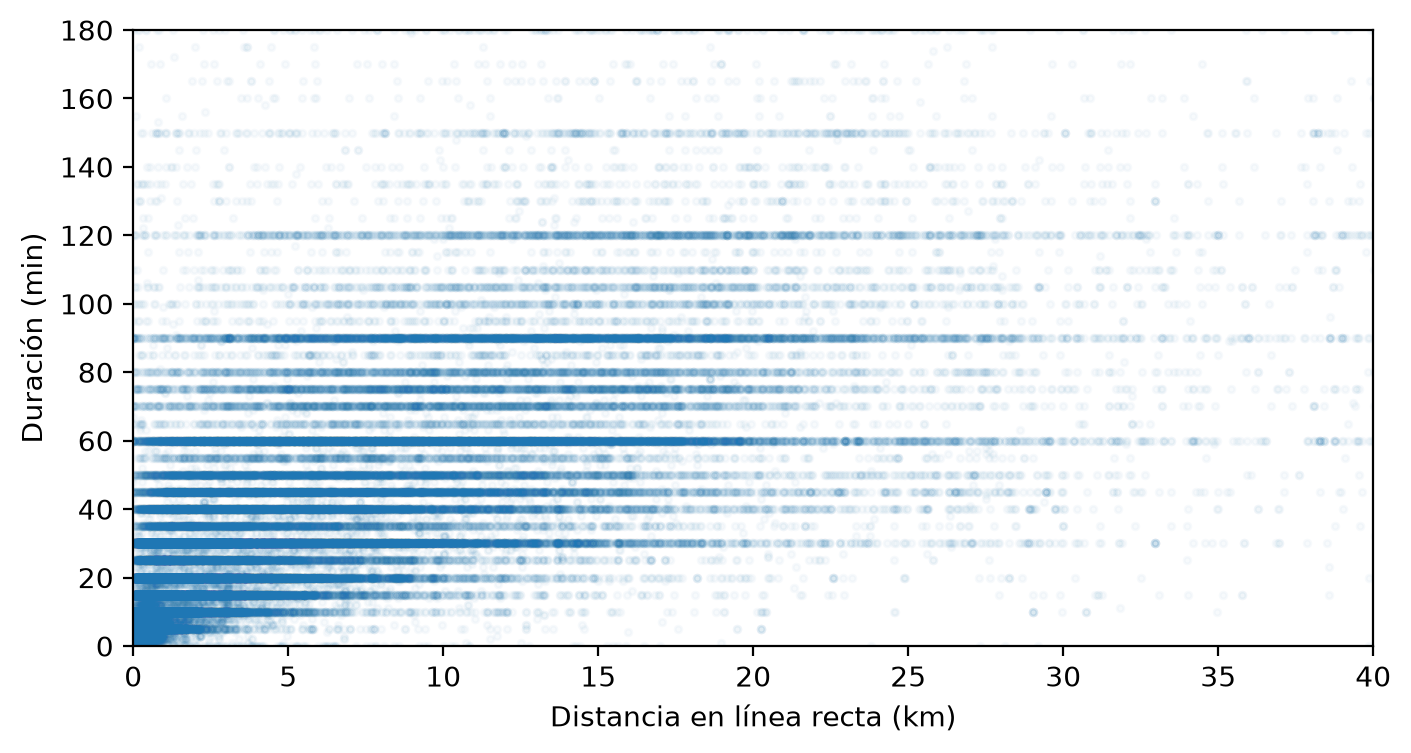

In [38]:
fig, ax = plt.subplots(figsize=(8, 4))
# alpha muy bajo: el color se acumula donde hay muchos puntos
ax.scatter(ok["DistKm"], ok["TiempoViaje"], s=6, alpha=0.03)
ax.set_xlim(0, 40)
ax.set_ylim(0, 180)
ax.set_xlabel("Distancia en línea recta (km)")
ax.set_ylabel("Duración (min)")
plt.show()

Las franjas horizontales son los tiempos redondeados (30, 45, 60): la moda de la clase 2, ahora en dos dimensiones. La alternativa es `hexbin`, donde el color cuenta los viajes por celda:

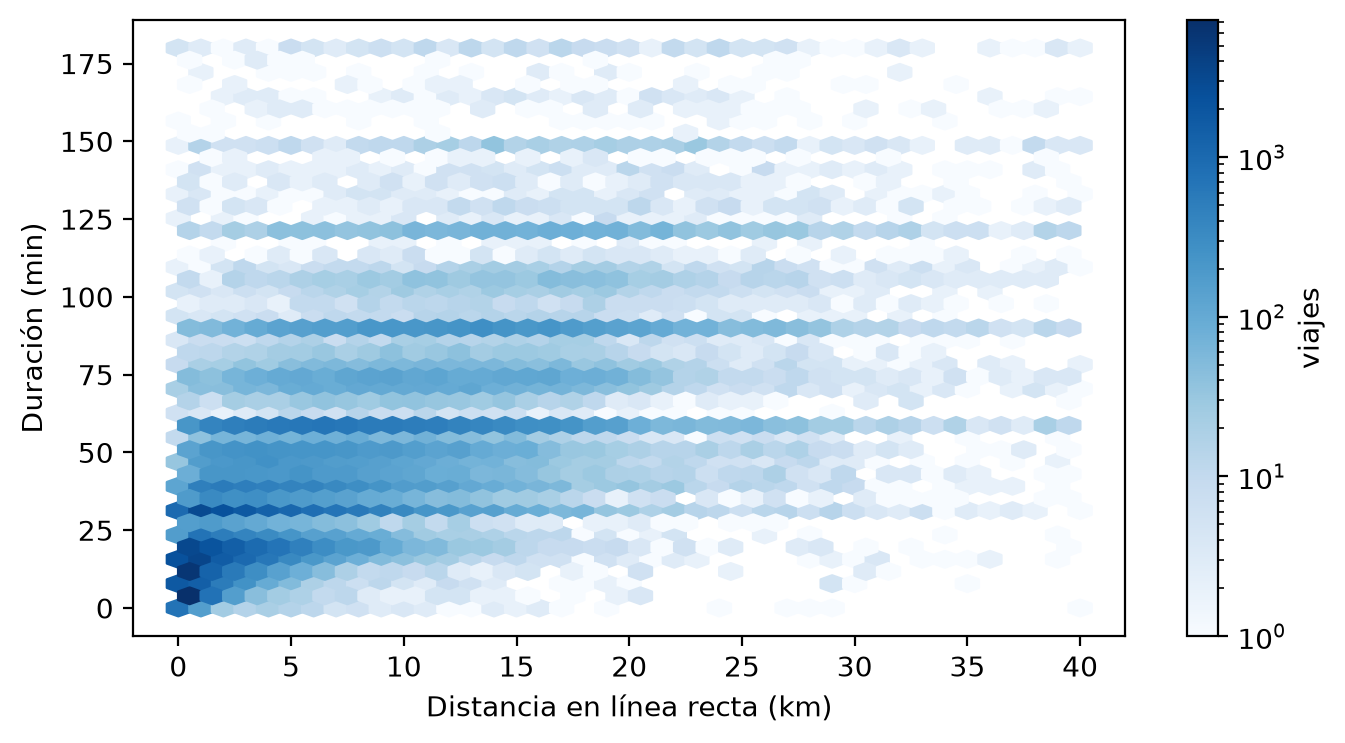

In [39]:
fig, ax = plt.subplots(figsize=(8, 4))

# hexbin divide el plano en celdas hexagonales y colorea cada una
# según cuántos puntos caen dentro. Sus parámetros:
#   gridsize: cuántas celdas caben a lo ancho (más = celdas más chicas)
#   cmap: el mapa de colores (aquí, blanco a azul)
#   mincnt: dibujar solo celdas con al menos ese número de puntos
#   extent: los límites del gráfico (x mínimo, x máximo, y mínimo, y máximo)
#   bins="log": el color en escala logarítmica; sin esto, la celda
#     más densa (7 mil viajes) deja al resto casi blanco
hb = ax.hexbin(ok["DistKm"], ok["TiempoViaje"], gridsize=40,
               cmap="Blues", mincnt=1, extent=(0, 40, 0, 180), bins="log")

ax.set_xlabel("Distancia en línea recta (km)")
ax.set_ylabel("Duración (min)")
# La barra de color traduce: qué tono corresponde a cuántos viajes
fig.colorbar(hb, label="viajes")
plt.show()

Cómo se lee: cada hexágono es una zona del plano, y su color dice cuántos viajes caen ahí (la barra de la derecha lo traduce, en escala logarítmica). Tres cosas a la vista:

1. La mancha más oscura está abajo a la izquierda: la gran mayoría de los viajes es corta en distancia y en tiempo.
2. La esquina de abajo a la derecha está casi vacía: los viajes largos en distancia nunca son cortos en tiempo. Esa asimetría es la asociación.
3. Las franjas horizontales oscuras en 30, 45, 60 y 90 minutos son los tiempos redondeados, ahora en dos dimensiones.

Nada de esto se veía en el scatter saturado. ¿Y cuánto vale la asociación?

In [40]:
print("Pearson: ", round(ok["DistKm"].corr(ok["TiempoViaje"]), 2))
print("Spearman:", round(ok["DistKm"].corr(ok["TiempoViaje"], method="spearman"), 2))

Pearson:  0.57
Spearman: 0.76


0,57 contra 0,76: cuando los dos coeficientes difieren, hay curvatura o atípicos, y la respuesta está en el gráfico (la misma brecha Pearson-Spearman de la clase 02, ahora en este universo de viajes).

El segundo problema: **colas largas**, y no hay que ir lejos: la misma distancia la tiene (mediana 3 km, máximo 137). En escala lineal la cola aplasta a la mayoría contra el borde; graficar el logaritmo reparte el espacio y la forma aparece:

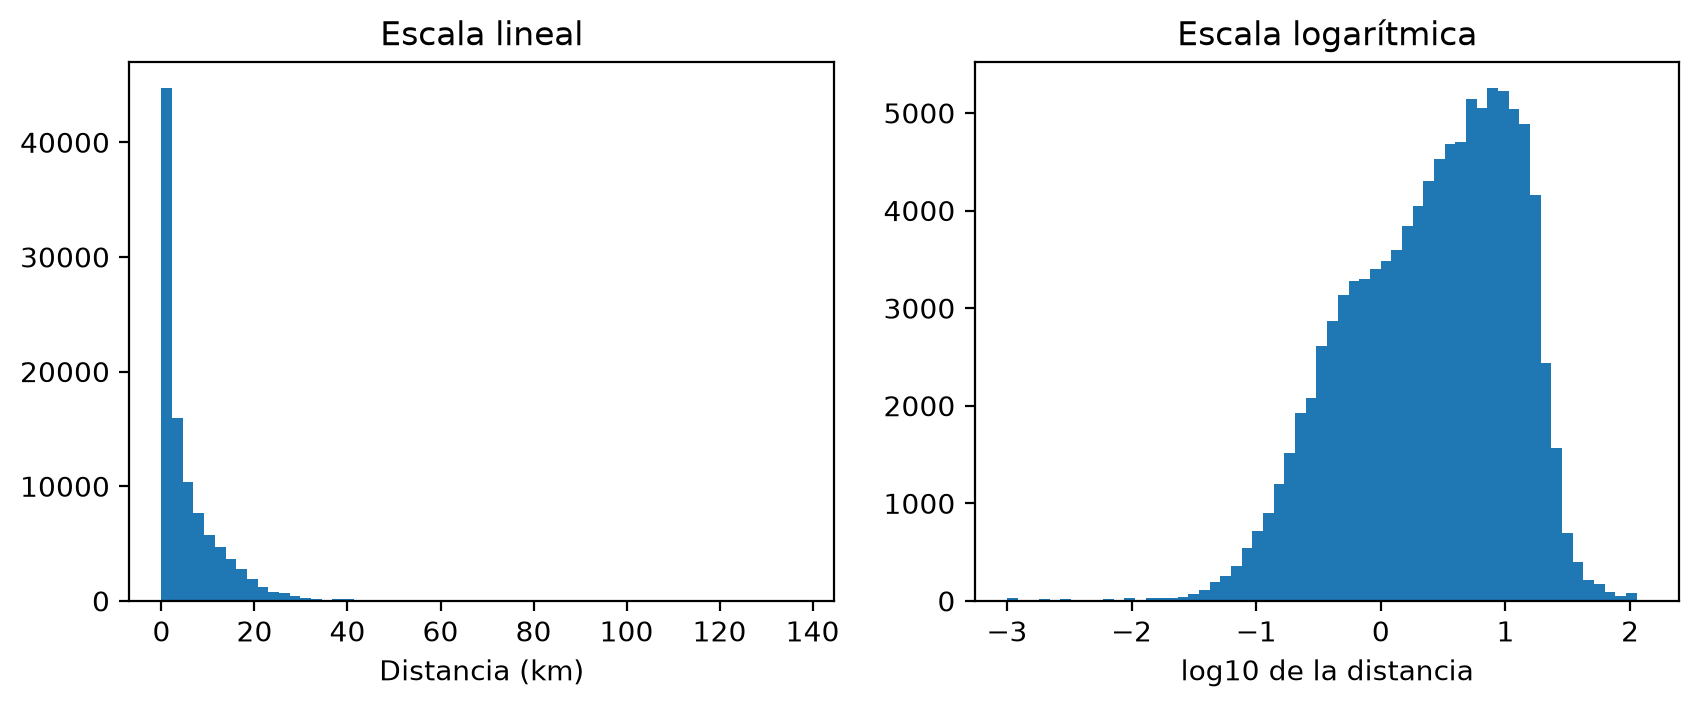

In [41]:
# El logaritmo no acepta ceros: fuera los 27 viajes que parten
# y llegan al mismo punto (distancia 0)
dist_pos = ok.loc[ok["DistKm"] > 0, "DistKm"]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(dist_pos, bins=60)
axes[0].set_title("Escala lineal")
axes[0].set_xlabel("Distancia (km)")
axes[1].hist(np.log10(dist_pos), bins=60)
axes[1].set_title("Escala logarítmica")
axes[1].set_xlabel("log10 de la distancia")
plt.show()

En log10, un 0 es 1 km y un 1 es 10 km: cada paso del eje multiplica por 10. Y los números negativos son las fracciones de kilómetro: −1 es 0,1 km (100 metros), −2 es 0,01 km (10 metros). El logaritmo baja de cero cuando la distancia baja de 1 km; no hay nada raro en esos valores, son los viajes muy cortos. La forma acampanada de la derecha estaba escondida en la barra pegada al borde de la izquierda.

¿Y para qué sirve? Dos usos concretos:

1. **Para explorar honestamente** cualquier variable con cola larga: ingresos, ventas, poblaciones, tiempos. Si su proyecto tiene una variable de dinero o de conteos, casi seguro la va a necesitar en su primer EDA.
2. **Para modelar**: aplicar el logaritmo a una variable es una transformación clásica de feature engineering. Cuando la relación entre x e y es multiplicativa (porcentual), en escala log se vuelve una recta, y la regresión lineal vuelve a servir. Lo veremos en las clases de regresión.

### La misma regresión, tres veces

**Objetivo:** cerrar usando lo aprendido: ¿qué modelo merecen estos datos? Ajustamos la misma regresión de statsmodels tres veces (sin log, con log en la distancia, con log en ambos lados) y comparamos los ajustes con el R² y con los gráficos:

In [42]:
# Sin logaritmo: duración ~ distancia
# Tiempo de viaje con distancia mayor a 0, para evitar problemas con el logaritmo
y = ok.loc[ok["DistKm"] > 0, "TiempoViaje"]

#Variable a predecir: duración del viaje
#Variable predictora: distancia del viaje
modelo_sin = sm.OLS(y, sm.add_constant(dist_pos)).fit()
modelo_sin.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            TiempoViaje   R-squared:                       0.323
Model:                            OLS   Adj. R-squared:                  0.323
Method:                 Least Squares   F-statistic:                 4.888e+04
Date:                Fri, 04 Sep 2026   Prob (F-statistic):               0.00
Time:                        11:57:42   Log-Likelihood:            -4.9052e+05
No. Observations:              102395   AIC:                         9.810e+05
Df Residuals:                  102393   BIC:                         9.811e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         23.4601      0.113    207.445      0.000      23.238      23.682
DistKm         2.4608      0.011    221.086      0.000       2.439       2.483
==============================================================================
Omnibus:                   139665.830   Durbin-Watson:                   1.432
Prob(Omnibus):                  0.000   Jarque-Bera (JB):        158944666.873
Skew:                           7.302   Prob(JB):                         0.00
Kurtosis:                     195.461   Cond. No.                         12.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [43]:
print("R² sin log:", round(modelo_sin.rsquared, 2))

R² sin log: 0.32


In [44]:
# Transformación logarítmica: duración ~ log(distancia)
modelo_con = sm.OLS(y, sm.add_constant(np.log10(dist_pos))).fit()
print("R² con log:", round(modelo_con.rsquared, 2))

R² con log: 0.34


De 0,32 a 0,34: la mejora es marginal. Pero sabemos que las dos variables tienen una cola larga. Cuando las dos variables son así, la transformación clásica es aplicar el logaritmo en ambos lados:

In [45]:
# El log tampoco acepta duraciones 0: fuera esos viajes
ll = ok[(ok["DistKm"] > 0) & (ok["TiempoViaje"] > 0)]

modelo_ll = sm.OLS(np.log10(ll["TiempoViaje"]),
                   sm.add_constant(np.log10(ll["DistKm"]))).fit()
print("R² log-log:", round(modelo_ll.rsquared, 2))

R² log-log: 0.53


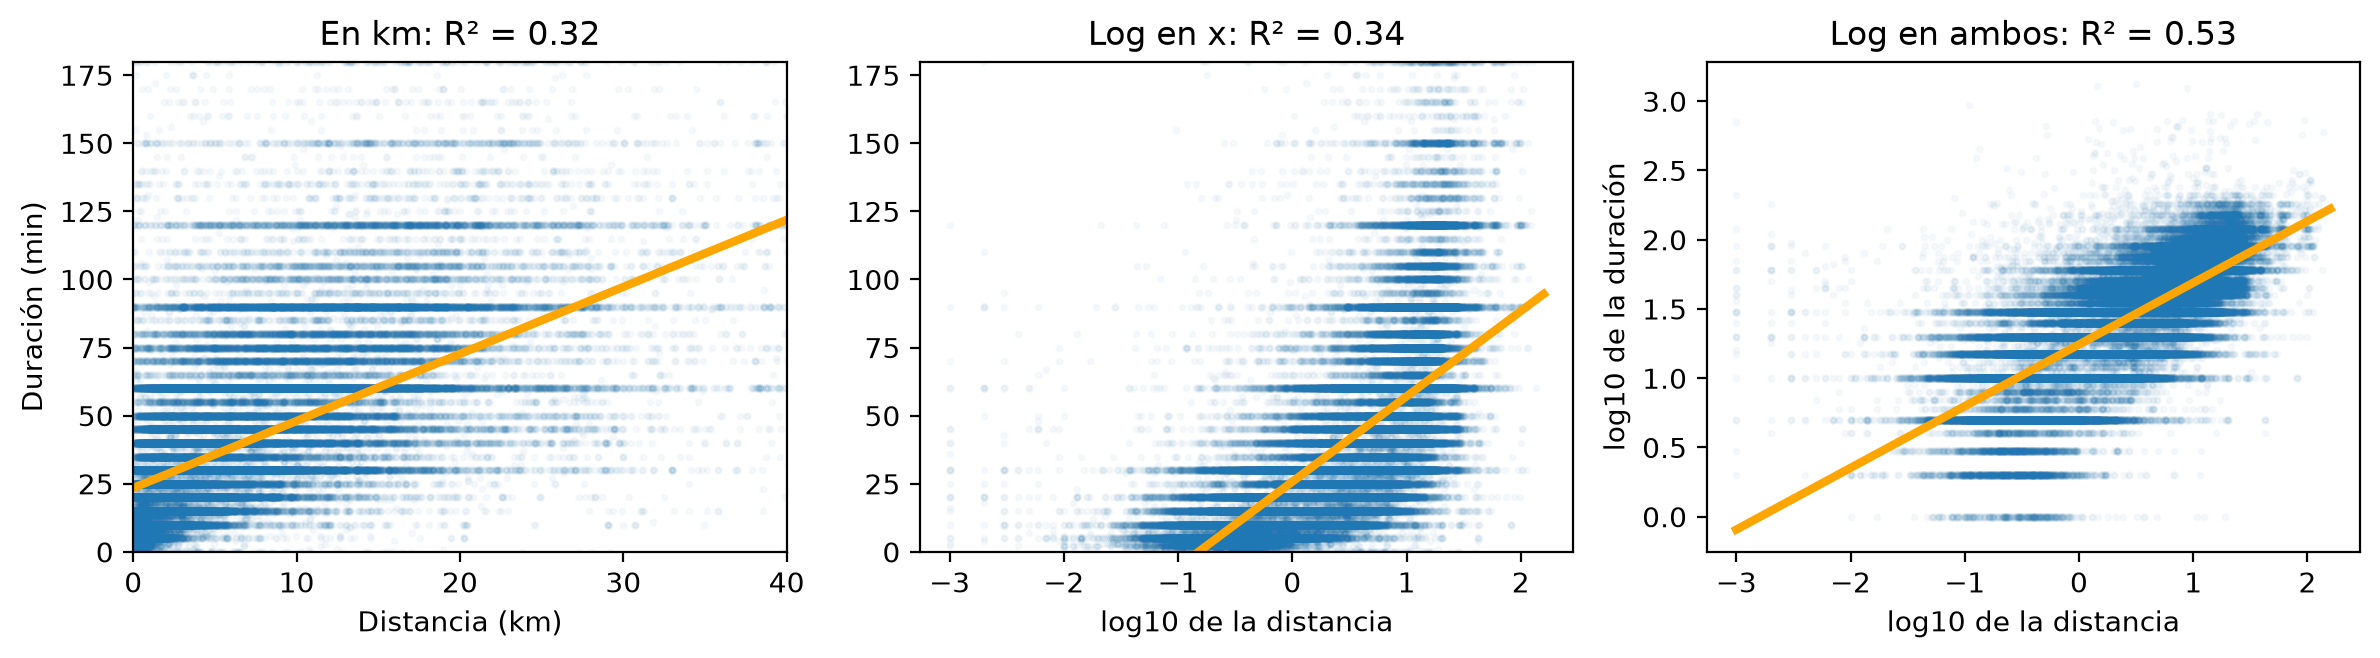

In [46]:
# Los tres modelos, lado a lado; ax.set(...) fija etiquetas,
# límites y título de un panel en una sola llamada
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))

# 1. Recta sobre los kilómetros
axes[0].scatter(dist_pos, y, s=4, alpha=0.03)
xs = np.linspace(0.01, 40, 100)
axes[0].plot(xs, modelo_sin.params.iloc[0] + modelo_sin.params.iloc[1] * xs,
             color="orange", lw=3)
axes[0].set(xlim=(0, 40), ylim=(0, 180), xlabel="Distancia (km)",
            ylabel="Duración (min)", title=f"En km: R² = {modelo_sin.rsquared:.2f}")

# 2. Log solo en la distancia
axes[1].scatter(np.log10(dist_pos), y, s=4, alpha=0.03)
xl = np.linspace(-3, 2.2, 100)
axes[1].plot(xl, modelo_con.params.iloc[0] + modelo_con.params.iloc[1] * xl,
             color="orange", lw=3)
axes[1].set(ylim=(0, 180), xlabel="log10 de la distancia",
            title=f"Log en x: R² = {modelo_con.rsquared:.2f}")

# 3. Log en ambos lados
axes[2].scatter(np.log10(ll["DistKm"]), np.log10(ll["TiempoViaje"]), s=4, alpha=0.03)
axes[2].plot(xl, modelo_ll.params.iloc[0] + modelo_ll.params.iloc[1] * xl,
             color="orange", lw=3)
axes[2].set(xlabel="log10 de la distancia", ylabel="log10 de la duración",
            title=f"Log en ambos: R² = {modelo_ll.rsquared:.2f}")

plt.tight_layout()
plt.show()

Los tres paneles, de izquierda a derecha:

1. **En km**, la nube queda comprimida contra el borde y la recta atraviesa zonas casi sin datos (R² 0,32).
2. **Con log solo en la distancia**, los puntos se reparten, pero la recta no calza con la forma de la nube y para los viajes de menos de 150 metros predice duraciones negativas (R² 0,34): una señal clara de que el modelo no es el adecuado.
3. **Con log en ambos lados**, la nube toma una forma aproximadamente lineal y la recta la describe: el R² sube a 0,53. La razón: las dos variables tienen cola larga, no solo una.

El modelo log-log se lee en forma multiplicativa: la pendiente 0,45 indica que cuando la distancia se multiplica por 10, la duración se multiplica por 10^0,45 ≈ 2,8 (unos 18 minutos en 1 km, 49 en 10 km). 

¿Qué modelo se usaría entonces para estos datos? Al menos este último, y todavía le faltan variables: el modo, la hora del día, la zona. Incorporarlas es exactamente lo que hace la regresión múltiple, el paso que damos ahora. Lo que muestra este cierre: transformar variables (feature engineering) puede mejorar un modelo tanto como elegir bien las variables, y el R² permite comparar las alternativas.

Con esto queda cerrado el arco de la clase 3: de la correlación a un modelo que ya se puede transformar, comparar y mejorar. Y quedó pedido el siguiente paso: más variables.

## 4. Regresión múltiple

**Objetivo:** pasar de una variable independiente a varias: el mismo método de mínimos cuadrados, ahora con más de un predictor.

La regresión múltiple modela

$$\hat{y} = a + b_1\,x_1 + b_2\,x_2 + \dots + b_k\,x_k$$

donde $\hat{y}$ es el valor predicho, cada $x_j$ es una variable independiente, cada $b_j$ dice cuánto cambia la predicción por una unidad de $x_j$ **manteniendo las demás constantes**, y $a$ es el intercepto. La frase en negrita es la gracia de la múltiple: cada coeficiente aísla el efecto de su variable.

### La motorización, con dos variables

**Objetivo:** ¿mejora el modelo de vehículos si además del ingreso usamos el tamaño del hogar?

**Qué queremos explicar:** los vehículos del hogar (`NumVeh`). **Con qué variables:** el ingreso (en millones) y las personas del hogar (`NumPer`).

In [47]:
h2 = hogares.dropna(subset=["IngresoHogar", "NumVeh", "NumPer",
                            "NumBicAdulto", "NumBicNino", "Factor"]).copy()
h2.head()

,Hogar,Sector,Zona,Comuna,DirCoordX,DirCoordY,Fecha,DiaAsig,TipoDia,Temporada,...,NumVeh,NumBicAdulto,NumBicNino,Propiedad,MontoDiv,ImputadoDiv,MontoArr,ImputadoArr,IngresoHogar,Factor
0,100010,7,786,BUIN,335180.8019,6266420.975,14-04-2013,domingo,2,1,...,1,1,0,2,53000.0,0,100000,0,450845,136.393738
1,100020,7,785,BUIN,338410.2114,6265607.141,10-04-2013,miércoles,1,1,...,1,3,0,1,NaN,0,120000,0,1019369,73.843597
2,100030,7,791,BUIN,327863.8248,6257800.086,23-08-2013,viernes,1,1,...,0,0,0,3,NaN,0,70000,0,80000,180.722809
3,100041,7,791,BUIN,327864.0000,6257800.000,23-08-2013,viernes,1,1,...,0,1,0,1,NaN,0,80000,0,559259,150.379059
4,100052,7,783,BUIN,338480.8152,6267296.941,08-08-2013,jueves,1,1,...,0,0,0,1,NaN,0,117771,1,710309,122.001518


In [48]:
# Dos variables independientes: el ingreso (millones) y las personas del hogar
X = sm.add_constant(pd.DataFrame({
    "ingreso": h2["IngresoHogar"] / 1e6,
    "personas": h2["NumPer"],
}))
modelo_2v = sm.WLS(h2["NumVeh"], X, weights=h2["Factor"]).fit()


print("R²:", round(modelo_2v.rsquared, 3))

R²: 0.266


In [49]:

print("R²:", round(modelo_w.rsquared, 3))

R²: 0.261


In [50]:
#imprimir el valor de los parámetros del modelo redondeados a 3 decimales
print(modelo_2v.params.round(3))

const       0.106
ingreso     0.484
personas    0.033
dtype: float64


El modelo ajustado quedó

$$\widehat{\text{vehículos}} = 0{,}106 + 0{,}484\,\text{ingreso} + 0{,}033\,\text{personas}$$

La lectura, coeficiente por coeficiente y siempre con la otra variable fija: cada millón de ingreso suma 0,48 vehículos (era 0,50 a solas), y cada persona adicional del hogar suma 0,03. El R² sube apenas, de 0,261 a 0,266: agregar una variable **nunca baja** el R², pero puede aportar casi nada. Distinguir cuándo un aporte es real es tema de la clase 5 (significancia) y de la 7 (regularización).

### Leer el modelo: R² y el valor p

**Objetivo:** entender los dos números que acompañan a toda regresión: cuánto explica el modelo y si cada variable aporta más que el azar.

El **R²** mide la fracción de la variabilidad de $y$ que el modelo explica:

$$R^2 = 1 - \frac{\sum_i (y_i - \hat{y}_i)^2}{\sum_i (y_i - \bar{y})^2}$$

donde $y_i$ es el valor observado, $\hat{y}_i$ el que predice el modelo e $\bar{y}$ la media de $y$. El numerador suma los errores del modelo al cuadrado; el denominador es la variabilidad total. R² = 0 significa que el modelo no explica nada más que la media; R² = 1, que predice exacto. Nuestro 0,266 se lee: el ingreso y las personas explican poco más de un cuarto de la variabilidad de los vehículos entre hogares.

El **valor p** de un coeficiente responde una sola pregunta sobre esa variable: si en la población (la ciudad) el ingreso no tuviera ningún efecto sobre los vehículos, es decir, si su coeficiente real fuera cero, ¿qué tan raro sería obtener en una muestra como esta un coeficiente como el nuestro, solo por azar del muestreo? Un p muy chico dice "esto no parece azar". Lo mismo se pregunta para las personas. En el `summary()` es la columna `P>|t|`:

In [51]:
# Los valores p de cada coeficiente
modelo_2v.pvalues

const       1.644991e-21
ingreso     0.000000e+00
personas    9.372941e-27
dtype: float64

¿Nos sirven estas variables? Las dos son **significativas** (p prácticamente 0): ninguna parece azar. La definición formal, con hipótesis y umbrales, se ve la próxima clase; por ahora basta la lectura.

### El mapa de correlaciones: ¿qué otra variable agregar?

**Objetivo:** usar la matriz de correlación como mapa para elegir la próxima variable del modelo.

La fila de `NumVeh` dice qué candidatas se asocian con lo que queremos predecir; el resto de la matriz avisa cuáles son redundantes entre sí:

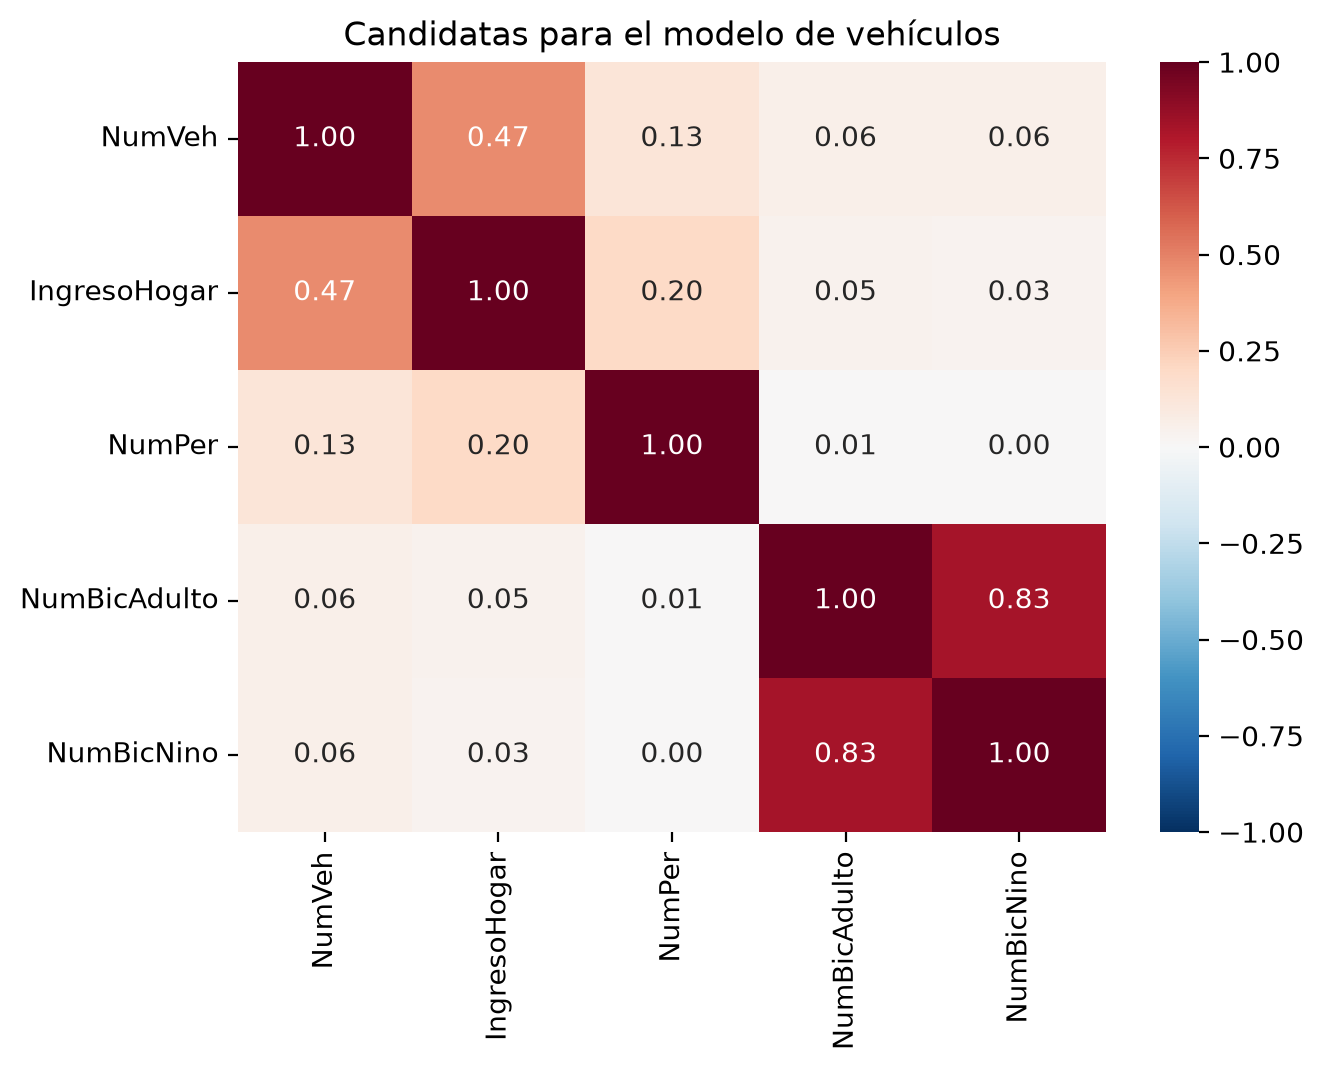

In [52]:
candidatas = ["NumVeh", "IngresoHogar", "NumPer", "NumBicAdulto", "NumBicNino"]
matriz = h2[candidatas].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(matriz, annot=True, fmt=".2f", cmap="RdBu_r",
            vmin=-1, vmax=1, ax=ax)
ax.set_title("Candidatas para el modelo de vehículos")
plt.show()

Lectura del mapa: el ingreso (0,47) es el motor del modelo y las personas (0,13) ya están dentro. Las bicicletas casi no correlacionan con los vehículos (0,06), y sí muchísimo entre ellas (0,83): son redundantes, el mismo patrón que la matriz de iris de las slides. El mapa anticipa que en esta tabla no queda mucho que agregar. Comprobémoslo con las bicicletas de adulto:

In [53]:
X = sm.add_constant(pd.DataFrame({
    "ingreso": h2["IngresoHogar"] / 1e6,
    "personas": h2["NumPer"],
    "bic_adulto": h2["NumBicAdulto"],
}))
modelo_3v = sm.WLS(h2["NumVeh"], X, weights=h2["Factor"]).fit()

print(modelo_3v.params.round(3))
print("R²:", round(modelo_3v.rsquared, 3))
print("p de bic_adulto:", f"{modelo_3v.pvalues['bic_adulto']:.1e}")

const         0.103
ingreso       0.482
personas      0.033
bic_adulto    0.003
dtype: float64
R²: 0.267
p de bic_adulto: 1.1e-08


El resultado junta las dos lecturas: el coeficiente es minúsculo (0,003 vehículos por bicicleta) y el R² sube solo de 0,266 a 0,267, pero el valor p es diminuto: la variable es **significativa**. Con 18 mil hogares, hasta un aporte minúsculo se distingue del azar. La lección que abre la próxima clase: **significativo no es sinónimo de importante**. El valor p dice "no es azar"; el tamaño del coeficiente y el R² dicen si vale la pena. El mapa de correlaciones lo había anticipado con su 0,06.

**Objetivo:** ver de una vez cómo cambian los coeficientes al agregar variables: del modelo con solo ingreso al de tres variables.

In [54]:
# Los tres modelos, coeficiente por coeficiente
coefs = pd.DataFrame({
    "solo ingreso": {"intercepto": modelo_w.params["const"],
                     "ingreso": modelo_w.params["IngresoHogar"]},
    "+ personas": {"intercepto": modelo_2v.params["const"],
                   "ingreso": modelo_2v.params["ingreso"],
                   "personas": modelo_2v.params["personas"]},
    "+ bicicletas": {"intercepto": modelo_3v.params["const"],
                     "ingreso": modelo_3v.params["ingreso"],
                     "personas": modelo_3v.params["personas"],
                     "bic_adulto": modelo_3v.params["bic_adulto"]},
})
coefs.round(3)

,solo ingreso,+ personas,+ bicicletas
intercepto,0.200,0.106,0.103
ingreso,0.501,0.484,0.482
personas,NaN,0.033,0.033
bic_adulto,NaN,NaN,0.003


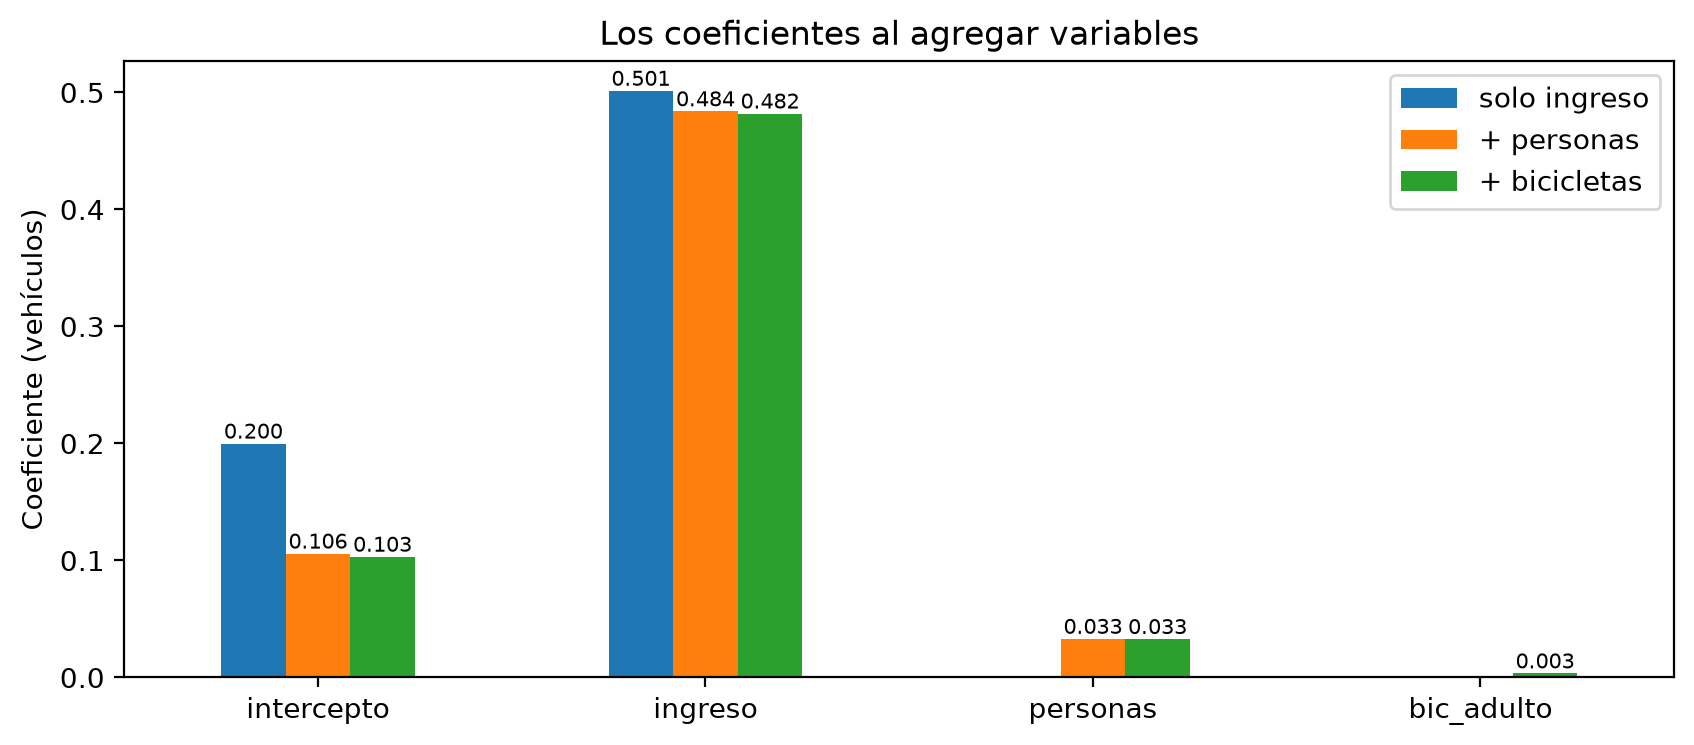

In [55]:
# El cambio de los coeficientes, en barras. Una barra ausente
# significa que la variable no está en ese modelo (pandas dibuja
# los NaN con altura 0, por eso no se etiquetan)
ax = coefs.plot(kind="bar", figsize=(10, 4), rot=0)
ax.set_ylabel("Coeficiente (vehículos)")
ax.set_title("Los coeficientes al agregar variables")
for barras in ax.containers:
    ax.bar_label(barras, fmt=lambda v: f"{v:.3f}" if v != 0 else "", fontsize=7.5)
plt.show()

El ingreso apenas se mueve (0,50 a 0,48) al agregar personas y bicicletas: es un efecto robusto, que no depende de qué más entra al modelo. Las variables nuevas entran con coeficientes minúsculos, y el intercepto baja porque las personas absorben parte del punto de partida.

### Duración con distancia y modo

**Objetivo:** decidir qué agregar al modelo log-log del cierre anterior, y agregarlo.

**Qué queremos explicar:** la duración del viaje (en log10). **Con qué variables:** la distancia (en log10) y lo que decidamos agregar.

Lo que ya sabemos: la duración correlaciona con la distancia (r = 0,57; Spearman 0,76) y el modelo log-log explica el 53% de su variabilidad. ¿Qué más podría explicarla? Primero, las candidatas numéricas que trae el hogar:

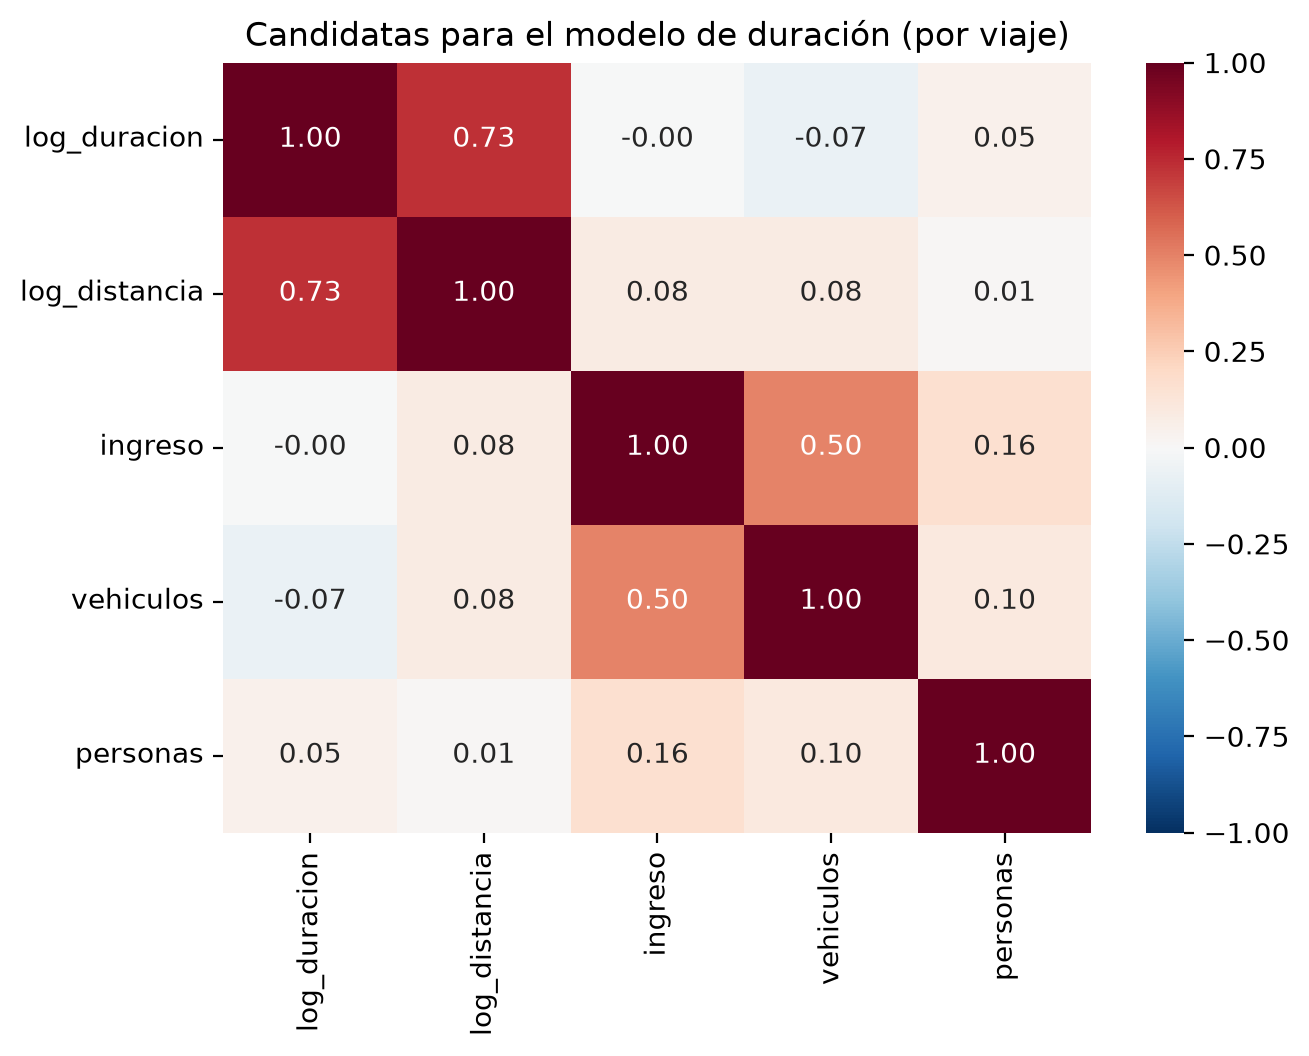

In [56]:
# El mapa de correlaciones, como en vehículos: duración y distancia
# en log (así entran al modelo) más las numéricas del hogar
ll_hogar = ll.merge(hogares[["Hogar", "IngresoHogar", "NumVeh", "NumPer"]], on="Hogar")
mapa = pd.DataFrame({
    "log_duracion": np.log10(ll_hogar["TiempoViaje"]),
    "log_distancia": np.log10(ll_hogar["DistKm"]),
    "ingreso": ll_hogar["IngresoHogar"] / 1e6,
    "vehiculos": ll_hogar["NumVeh"],
    "personas": ll_hogar["NumPer"],
}).corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(mapa, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax)
ax.set_title("Candidatas para el modelo de duración (por viaje)")
plt.show()

La fila de la duración: la distancia (0,73 en log) es el motor; el ingreso da **0,00**, los vehículos −0,07 y las personas 0,05. Ojo con el ingreso: en la recta por comuna su correlación con la duración era −0,34, pero eso era **entre comunas**. Un promedio por comuna esconde la variabilidad de los viajes individuales, y a nivel de viaje la relación desaparece: la escala del análisis cambia la respuesta.

Las numéricas del hogar no ayudan. Pero el mapa solo ve numéricas: las candidatas **categóricas** (el modo, el período del día, el propósito) hay que mirarlas con groupby. Traemos el modo de cada viaje:

In [57]:
# El modo de cada viaje, con los merges de la clase 02
modo_por_viaje = pd.read_csv(BASE + "ViajesDifusion.csv", sep=";")
nombres_modo = pd.read_csv(BASE + "tablas_parametros/ModoDifusion.csv", sep=";")
nombres_modo = nombres_modo.rename(columns={"ModoDifusion": "NombreModo"})

ll_modo = (ll
    .merge(modo_por_viaje, on="Viaje")
    .merge(nombres_modo, left_on="ModoDifusion", right_on="ID"))
ll_modo["ModoAgrupado"] = ll_modo["NombreModo"].where(
    ~ll_modo["NombreModo"].str.startswith("Bip!"),
    "Bip! (solo o combinado)")
len(ll_modo)

102223

In [58]:
ll_modo.head()

,Hogar,Persona,Viaje,Etapas,ComunaOrigen,ComunaDestino,SectorOrigen,SectorDestino,ZonaOrigen,ZonaDestino,...,FactorFindesemanaEstival,CodigoTiempo,DistEuclidiana,DistManhattan,Imputada,DistKm,ModoDifusion,ID,NombreModo,ModoAgrupado
0,173431,17343102,1734310202,1,94.0,94.0,2.0,2.0,400,407,...,NaN,0.0,5387,7608,0,5.387,2,2,Bip!,Bip! (solo o combinado)
1,173441,17344101,1734410101,2,94.0,71.0,2.0,3.0,407,307,...,NaN,0.0,18841,26100,0,18.841,2,2,Bip!,Bip! (solo o combinado)
2,173441,17344101,1734410102,2,71.0,94.0,3.0,2.0,307,407,...,NaN,0.0,18841,26100,0,18.841,2,2,Bip!,Bip! (solo o combinado)
3,173441,17344103,1734410301,2,94.0,91.0,2.0,3.0,407,437,...,NaN,0.0,13392,17589,0,13.392,2,2,Bip!,Bip! (solo o combinado)
4,173441,17344103,1734410302,2,91.0,94.0,3.0,2.0,437,407,...,NaN,0.0,13392,17589,0,13.392,2,2,Bip!,Bip! (solo o combinado)


In [59]:
# Por modo: duración media y distancia mediana
ll_modo.groupby("ModoAgrupado").agg(
    duracion_media=("TiempoViaje", "mean"),
    distancia_mediana=("DistKm", "median"),
    viajes=("TiempoViaje", "size"),
).round(1).sort_values("duracion_media", ascending=False)

,duracion_media,distancia_mediana,viajes
ModoAgrupado,,,
Bip! (solo o combinado),61.8,7.5,34659
Otros,46.1,4.0,7967
Taxi Colectivo,32.1,2.7,3400
Auto,31.5,4.4,25046
Taxi,25.0,2.2,1595
Bicicleta,24.7,1.6,3425
Caminata,14.9,0.4,26131


Contraste enorme: Bip! 62 minutos, auto 32, caminata 15. Pero la segunda columna avisa: los viajes en Bip! también son más largos en distancia (7,5 km contra 0,4 de caminata). Comparar duraciones a secas mezcla el modo con la distancia; por eso el modelo múltiple: controla la distancia y deja el efecto del modo **a igual distancia**.

**Decisión:** agregamos el modo. Es la candidata de mayor contraste, responde una pregunta de equidad, y como es texto nos obliga a aprender cómo entra una categórica al modelo. El período del día, la otra candidata fuerte (punta mañana 60 minutos, fuera de punta 32), queda para el ejercicio.

Una categórica no entra tal cual a la fórmula: se convierte en **variables indicadoras** (dummies) con `pd.get_dummies`, una columna 0/1 por categoría. Una categoría se deja fuera como **referencia** (aquí, el auto), y cada coeficiente se lee "comparado con un viaje en auto".

In [60]:
# Las dummies: una columna 0/1 por modo; el auto, de referencia
dummies = pd.get_dummies(ll_modo["ModoAgrupado"]).astype(float).drop(columns=["Auto"])
dummies.head()

,Bicicleta,Bip! (solo o combinado),Caminata,Otros,Taxi,Taxi Colectivo
0,0.0,1.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,1.0,0.0,0.0,0.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0


In [61]:
# El texto original al lado de sus columnas 0/1: un solo 1 por fila,
# y toda en 0 si el viaje es en auto
pd.concat([ll_modo[["ModoAgrupado"]], dummies], axis=1).head(8)

,ModoAgrupado,Bicicleta,Bip! (solo o combinado),Caminata,Otros,Taxi,Taxi Colectivo
0,Bip! (solo o combinado),0.0,1.0,0.0,0.0,0.0,0.0
1,Bip! (solo o combinado),0.0,1.0,0.0,0.0,0.0,0.0
2,Bip! (solo o combinado),0.0,1.0,0.0,0.0,0.0,0.0
3,Bip! (solo o combinado),0.0,1.0,0.0,0.0,0.0,0.0
4,Bip! (solo o combinado),0.0,1.0,0.0,0.0,0.0,0.0
5,Auto,0.0,0.0,0.0,0.0,0.0,0.0
6,Auto,0.0,0.0,0.0,0.0,0.0,0.0
7,Auto,0.0,0.0,0.0,0.0,0.0,0.0


In [62]:
X = sm.add_constant(pd.concat(
    [np.log10(ll_modo["DistKm"]).rename("log_dist"), dummies], axis=1))
modelo_modo = sm.OLS(np.log10(ll_modo["TiempoViaje"]), X).fit()




In [63]:
print("R² solo distancia:", round(modelo_ll.rsquared, 2),
      "| con modo:", round(modelo_modo.rsquared, 2))

R² solo distancia: 0.53 | con modo: 0.6


In [64]:
print(modelo_modo.params.round(2))

const                      1.15
log_dist                   0.37
Bicicleta                  0.07
Bip! (solo o combinado)    0.27
Caminata                   0.03
Otros                      0.20
Taxi                       0.01
Taxi Colectivo             0.13
dtype: float64


El modelo ajustado quedó

$$\widehat{\log_{10}(\text{duración})} = 1{,}15 + 0{,}37\,\log_{10}(\text{dist}) + 0{,}27\,\text{Bip!} + \dots$$

donde los puntos suspensivos son las dummies de los demás modos. El R² sube de 0,53 a 0,60, y los coeficientes de las dummies se leen en potencias de 10, igual que en el modelo log-log: $10^{0{,}27} \approx 1{,}87$ para Bip! significa que, **a igual distancia**, un viaje en transporte público tarda casi el doble que uno en auto. El taxi queda prácticamente igual al auto (1,02) y la caminata apenas encima (1,07). Un hallazgo de equidad urbana sacado de un modelo de tres líneas: el tiempo castiga al transporte público.

Dos advertencias para llevarse: los coeficientes describen **asociación**, no causalidad; y elegir variables, revisar diagnósticos y decidir qué es significativo es justamente el contenido de las clases 5, 6 y 7.

**Objetivo:** leer la dummy con números: el mismo viaje de 5 km, en auto y en Bip!.

Como el modelo está en log, la dummy **suma** 0,27 al log de la duración. Y sumar en log es multiplicar en la escala original. Hagamos la cuenta:

In [65]:
# El mismo viaje de 5 km, con la dummy en 0 (auto) y en 1 (Bip!)
b = modelo_modo.params
log_auto = b["const"] + b["log_dist"] * np.log10(5)      # Bip! = 0
log_bip = log_auto + b["Bip! (solo o combinado)"]         # Bip! = 1

print("auto:", round(10**log_auto, 1), "min | Bip!:", round(10**log_bip, 1), "min")
print("razón:", round(10**log_bip / 10**log_auto, 2), "= 10 elevado a", round(b["Bip! (solo o combinado)"], 2))

auto: 25.6 min | Bip!: 47.8 min
razón: 1.87 = 10 elevado a 0.27


Paso a paso, con la ecuación completa (todas las dummies):

$$\log_{10}(\text{dur}) = 1{,}15 + 0{,}37\,\log_{10}(\text{dist}) + 0{,}07\,\text{Bici} + 0{,}27\,\text{Bip!} + 0{,}03\,\text{Cam} + 0{,}20\,\text{Otros} + 0{,}01\,\text{Taxi} + 0{,}13\,\text{Colect}$$

En auto, 5 km (log10 5 = 0,70) y todas las dummies en 0:

$$1{,}15 + 0{,}37 \cdot 0{,}70 + 0{,}07 \cdot 0 + 0{,}27 \cdot 0 + 0{,}03 \cdot 0 + 0{,}20 \cdot 0 + 0{,}01 \cdot 0 + 0{,}13 \cdot 0 = 1{,}41 \Rightarrow \text{dur} = 10^{1{,}41} = 25{,}6 \text{ min}$$

En Bip!, 5 km y solo la dummy de Bip! en 1:

$$1{,}15 + 0{,}37 \cdot 0{,}70 + 0{,}07 \cdot 0 + 0{,}27 \cdot 1 + 0{,}03 \cdot 0 + 0{,}20 \cdot 0 + 0{,}01 \cdot 0 + 0{,}13 \cdot 0 = 1{,}68 \Rightarrow \text{dur} = 10^{1{,}68} = 47{,}8 \text{ min}$$

La razón 47,8 / 25,6 = 1,87 es exactamente 10^0,27. Esa es la lectura de una dummy en un modelo en log: su coeficiente, elevado 10, es **cuántas veces** cambia la variable respecto de la referencia, a igual valor de las demás.

¿Por qué se **dividen** los dos tiempos y no se restan? Porque la dummy actúa en la escala log, y una resta en log es una división en la escala original:

$$\log_{10}(47{,}8) - \log_{10}(25{,}6) = 0{,}27 \quad\Longleftrightarrow\quad \frac{47{,}8}{25{,}6} = 10^{0{,}27} = 1{,}87$$

Si restáramos minutos, el resultado dependería de la distancia: a 5 km la resta es de 22 minutos, a 1 km sería cerca de la mitad y a 20 km casi el doble. La razón, en cambio, es 1,87 a cualquier distancia: por eso es la lectura correcta del coeficiente. Sin log, la lectura sería aditiva: tantos minutos más, a igual distancia.

### Advertencia: el R² ajustado

El R² **nunca baja** al agregar una variable, aunque sea ruido: mínimos cuadrados siempre puede usar un coeficiente más para acomodar un poco mejor los datos. Por eso, para comparar modelos con distinto número de variables se usa el **R² ajustado**, que descuenta cada variable extra:

$$R^2_{\text{adj}} = 1 - (1 - R^2)\,\frac{n - 1}{n - k - 1}$$

donde $n$ es el número de observaciones y $k$ el de variables independientes. Si la variable nueva aporta menos de lo que se esperaría por azar, el ajustado baja. En statsmodels es `rsquared_adj` (en el `summary()`, "Adj. R-squared"). Comparemos los dos en todos los modelos de hoy:

In [66]:
modelos = {
    "vehículos ~ ingreso": modelo_w,
    "vehículos ~ ingreso + personas": modelo_2v,
    "vehículos ~ ingreso + personas + bicicletas": modelo_3v,
    "log duración ~ log distancia": modelo_ll,
    "log duración ~ log distancia + modo": modelo_modo,
}
for nombre, m in modelos.items():
    print(f"{nombre:45s} n = {int(m.nobs):>6}  k = {int(m.df_model)}  "
          f"R² = {m.rsquared:.4f}  ajustado = {m.rsquared_adj:.4f}")

vehículos ~ ingreso                           n =  18264  k = 1  R² = 0.2613  ajustado = 0.2612
vehículos ~ ingreso + personas                n =  18264  k = 2  R² = 0.2659  ajustado = 0.2658
vehículos ~ ingreso + personas + bicicletas   n =  18264  k = 3  R² = 0.2672  ajustado = 0.2671
log duración ~ log distancia                  n = 102223  k = 1  R² = 0.5334  ajustado = 0.5334
log duración ~ log distancia + modo           n = 102223  k = 7  R² = 0.6023  ajustado = 0.6023


Con nuestros n (18 mil hogares, 102 mil viajes) el ajustado es idéntico al R² hasta el tercer decimal, así que ninguna conclusión de hoy cambia. Pero con pocos datos la diferencia es grande: un R² de 0,266 con n = 30 y k = 3 se convierte en un ajustado de 0,18. En sus proyectos, con cientos de filas y no cien mil, comparen modelos con el R² ajustado.

## 5. Ejercicio 

Con los datos de su comuna de la Tarea 1 (o con la EOD completa):

1. Mida el impacto de su fila más extrema: un resumen con y sin ella.
2. Revise los atípicos de su variable a predecir con un boxplot y la cerca de Tukey: ¿son errores o son la señal?
3. Ajuste una regresión simple y una múltiple con statsmodels y compare sus R².
4. Con la EOD: agregue el período del día (`Periodo`) al modelo de duración como dummies. ¿Cuánto sube el R² y qué período castiga más?
5. Con la EOD: el mapa dice que el ingreso correlaciona 0,00 con la duración por viaje, pero entre comunas (clase 3) daba −0,34. Agregue el ingreso del hogar al modelo de duración (la llave es `Hogar`) y mire R², coeficiente y valor p. ¿Qué aporta? ¿Cómo se explica la diferencia entre las dos escalas?



In [67]:
# Su solución


---

**Próxima clase (viernes 25-sep):** inferencia estadística: qué significa el valor p que statsmodels ya nos mostró. Ese día también se rinde el control Q2 y se entrega la propuesta de proyecto. Recuerde: la Tarea 1 se entrega el jueves 10 de septiembre por Aula, y no hay clases el 11 ni el 18.